In [12]:
import numpy as np
import scipy.signal as sp_signal
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, freqz
import soundfile as sf

In [ ]:
# 1. Load audio file using soundfile
audio_file = ''
data, fs = sf.read(audio_file)

In [14]:
# Data normalization if file was in int format (int16 or int32)
if np.issubdtype(data.dtype, np.integer):
    data = data / np.iinfo(data.dtype).max

# Convert stereo to mono if data is 2-dimensional
if len(data.shape) == 2:
    data = data.mean(axis=1)

time = np.arange(len(data)) / fs  # Time axis


In [15]:
# 2. Moving average filter with window 15
def moving_average_filter(signal, window_length):
    ma_filter = np.ones(window_length) / window_length
    filtered_signal = np.convolve(signal, ma_filter, mode='same')
    return filtered_signal


# Apply moving average filter with window = 15
ma_window_15_signal = moving_average_filter(data, window_length=15)

In [16]:

# 3. Dynamic noise reduction in STFT domain
def adaptive_spectral_subtraction(audio_signal, fs, noise_floor_db=-70):
    n_fft = 4096  # FFT window size
    hop_length = 2048  # Window hop

    # STFT computation
    f, t, Zxx = sp_signal.stft(audio_signal, fs=fs, nperseg=n_fft, noverlap=hop_length)
    magnitude = np.abs(Zxx)
    phase = np.angle(Zxx)

    # Noise modeling (based on quietest signal values)
    noise_profile = np.percentile(magnitude, 5, axis=1, keepdims=True)
    noise_amplitude = np.maximum(noise_profile, 10 ** (noise_floor_db / 20))

    # Noise reduction with adaptive thresholding
    magnitude_clean = np.maximum(magnitude - 0.5 * noise_amplitude, 0)

    # Signal reconstruction
    Zxx_clean = magnitude_clean * np.exp(1j * phase)
    _, clean_signal = sp_signal.istft(Zxx_clean, fs=fs, nperseg=n_fft, noverlap=hop_length)
    return clean_signal

In [17]:

# 4. Remove low amplitude frequencies
def remove_low_amplitude_frequencies(audio_signal, threshold_db=-50):
    # STFT computation
    f, t, Zxx = sp_signal.stft(audio_signal, fs=fs, nperseg=4096, noverlap=1024)
    magnitude = np.abs(Zxx)
    phase = np.angle(Zxx)

    # Amplitude threshold
    threshold = 10 ** (threshold_db / 10.0)

    # Remove frequencies below threshold
    magnitude[magnitude < threshold] = 0.0

    # Signal reconstruction after removal
    Zxx_filtered = magnitude * np.exp(1j * phase)
    _, final_signal = sp_signal.istft(Zxx_filtered, fs=fs, nperseg=4096, noverlap=1024)
    return final_signal

In [18]:
# 5. FIR Filters
filter_order = 101

# Low-pass filter (LPF)
cutoff_low = 3000  # Hz
lpf = firwin(filter_order, cutoff_low, fs=fs, pass_zero=True)
lpf_filtered = lfilter(lpf, 1.0, data)

# High-pass filter (HPF)
cutoff_high = 300  # Hz
hpf = firwin(filter_order, cutoff_high, fs=fs, pass_zero=False)
hpf_filtered = lfilter(hpf, 1.0, data)

# Band-pass filter (BPF)
bandpass = [300, 3000]  # Hz
bpf = firwin(filter_order, bandpass, fs=fs, pass_zero='bandpass')
bpf_filtered = lfilter(bpf, 1.0, data)

In [19]:
# 6. Adaptive filtering processes for each filter:
def apply_adaptive_filters(signal, fs):
    # Adaptive filtering (spectral subtraction)
    spectral_signal = adaptive_spectral_subtraction(signal, fs)
    # Low amplitude removal filtering
    final_signal = remove_low_amplitude_frequencies(spectral_signal, threshold_db=-50)
    return final_signal

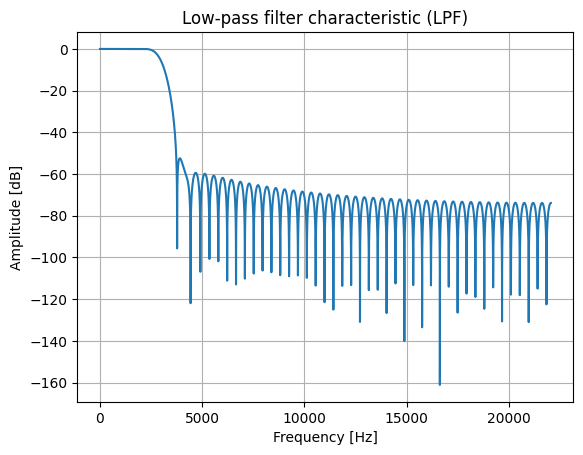

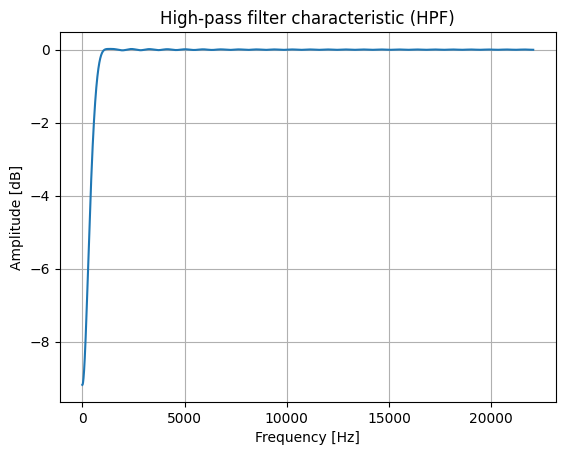

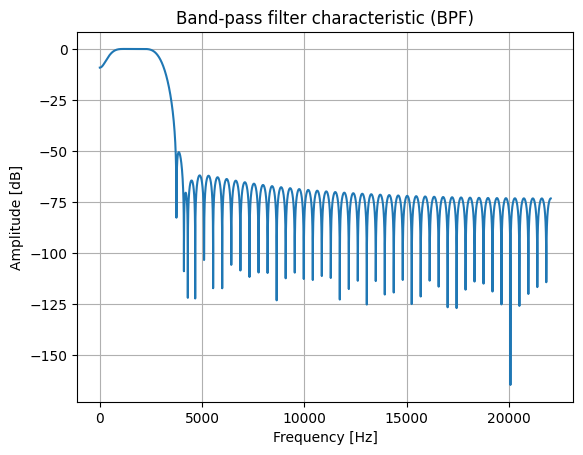

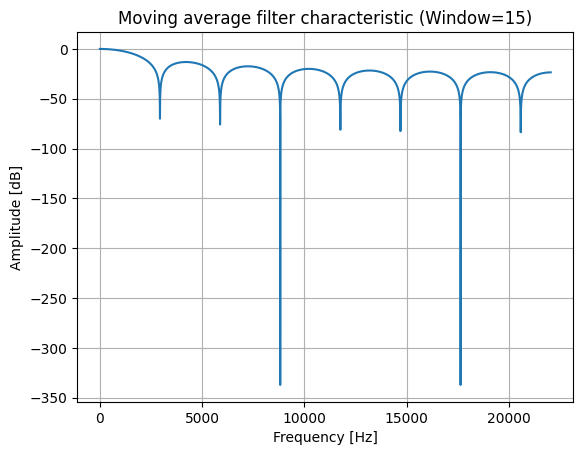

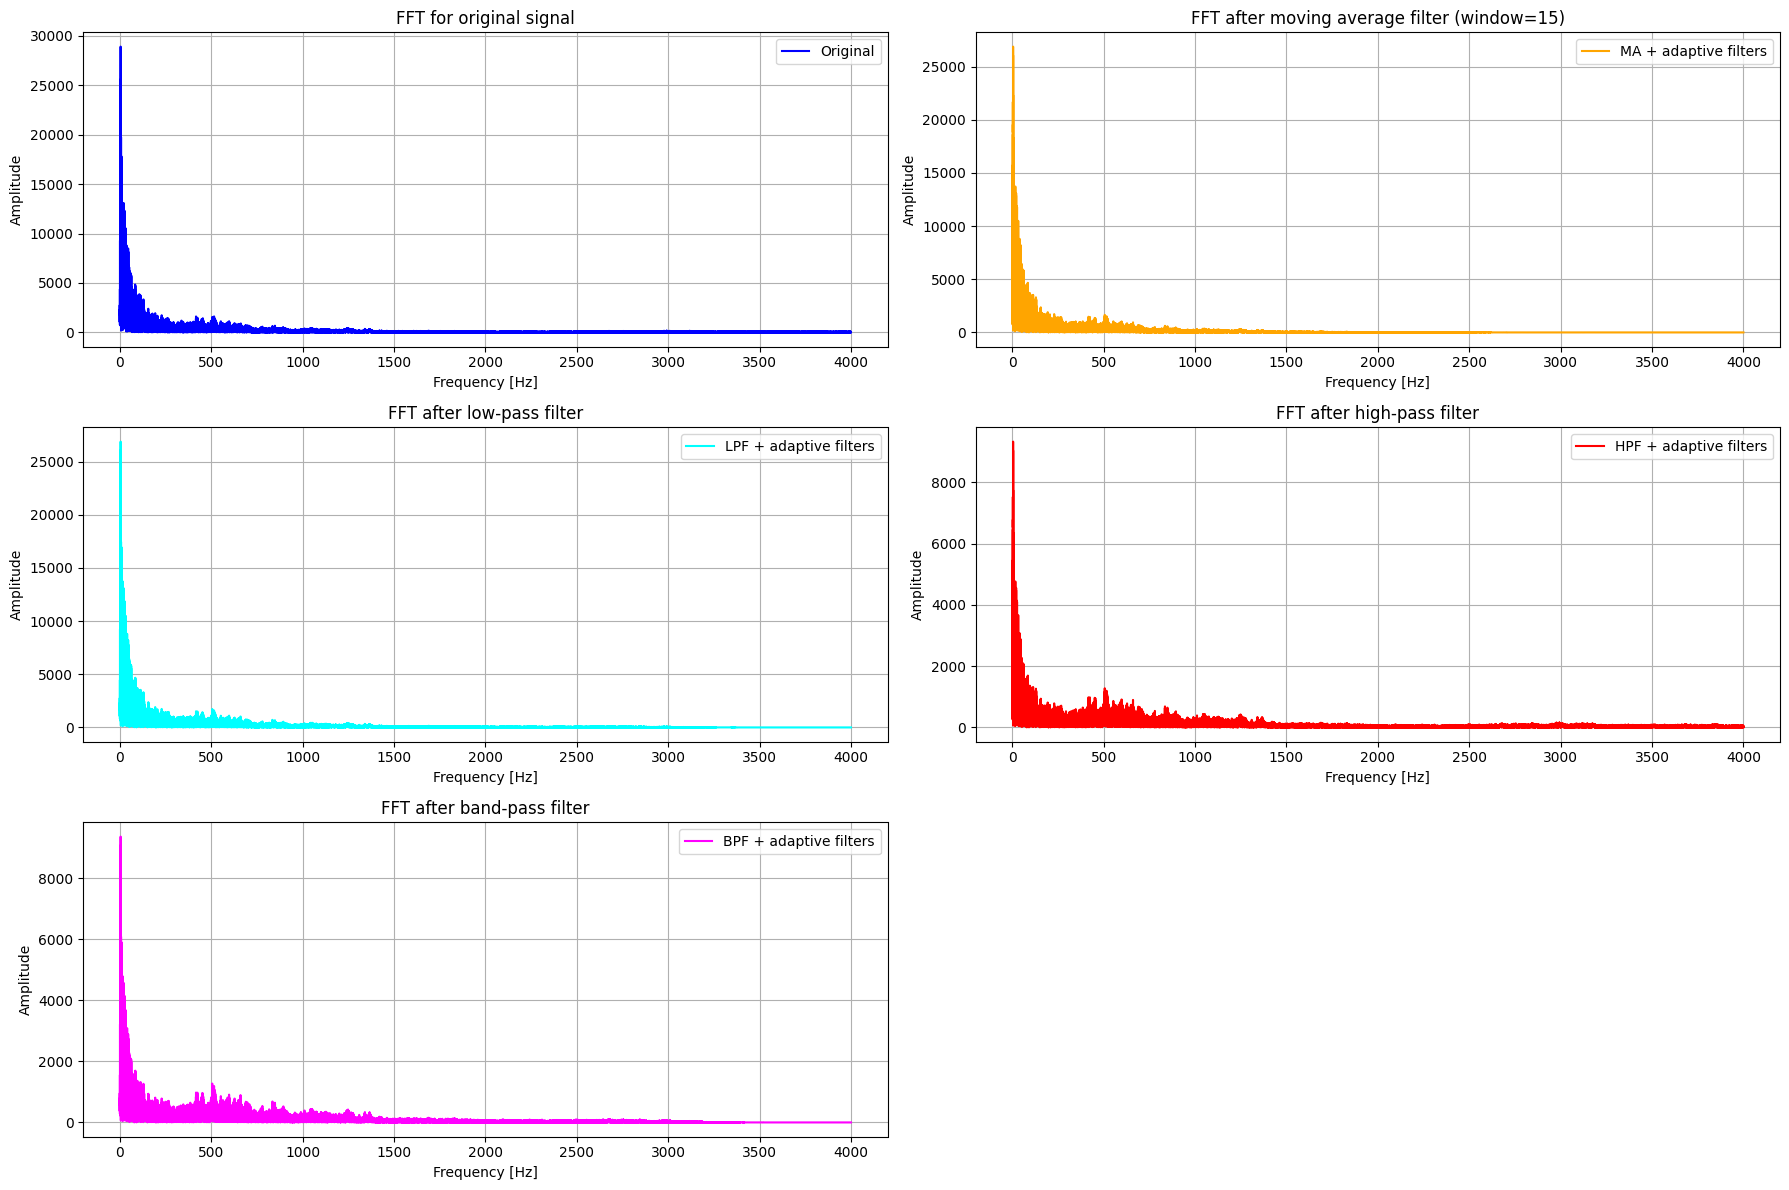

Signals have been saved to WAV files!


In [20]:
# Adaptive filtering results
ma_window_15_final = apply_adaptive_filters(ma_window_15_signal, fs)
lpf_final = apply_adaptive_filters(lpf_filtered, fs)
hpf_final = apply_adaptive_filters(hpf_filtered, fs)
bpf_final = apply_adaptive_filters(bpf_filtered, fs)


# Display filter characteristics
def display_filter_characteristics(filter_coefficients, fs, title):
    w, h = freqz(filter_coefficients, worN=8000, fs=fs)
    plt.plot(w, 20 * np.log10(abs(h)), label="Filter characteristic")
    plt.title(title)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude [dB]")
    plt.grid()
    plt.show()


# Low-pass filter characteristic (LPF)
display_filter_characteristics(lpf, fs, "Low-pass filter characteristic (LPF)")

# High-pass filter characteristic (HPF)
display_filter_characteristics(hpf, fs, "High-pass filter characteristic (HPF)")

# Band-pass filter characteristic (BPF)
display_filter_characteristics(bpf, fs, "Band-pass filter characteristic (BPF)")

# Moving average filter characteristic
ma_filter = np.ones(15) / 15
display_filter_characteristics(ma_filter, fs, "Moving average filter characteristic (Window=15)")


# 7. FFT calculations and plots
def compute_fft(signal, fs):
    n = len(signal)
    freq = np.fft.rfftfreq(n, 1 / fs)  # Frequencies
    fft_values = np.abs(np.fft.rfft(signal))  # Amplitudes
    return freq, fft_values


# FFT for original signal
freq_original, fft_original = compute_fft(data, fs)

# FFT after moving average filter
freq_ma, fft_ma = compute_fft(ma_window_15_final, fs)

# FFT after low-pass filter
freq_lpf, fft_lpf = compute_fft(lpf_final, fs)

# FFT after high-pass filter
freq_hpf, fft_hpf = compute_fft(hpf_final, fs)

# FFT after band-pass filter
freq_bpf, fft_bpf = compute_fft(bpf_final, fs)


# 8. FFT plots limited to 4000 Hz
def plot_fft_limited(freq, fft_values, title, color, label):
    mask = freq <= 4000  # Mask limiting spectrum to 4000 Hz
    plt.plot(freq[mask], fft_values[mask], color=color, label=label)
    plt.title(title)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid()


plt.figure(figsize=(18, 12))

# Original signal
plt.subplot(3, 2, 1)
plot_fft_limited(freq_original, fft_original,
                 'FFT for original signal', 'blue', 'Original')

# Moving average filter with adaptive methods
plt.subplot(3, 2, 2)
plot_fft_limited(freq_ma, fft_ma,
                 'FFT after moving average filter (window=15)', 'orange', 'MA + adaptive filters')

# Low-pass
plt.subplot(3, 2, 3)
plot_fft_limited(freq_lpf, fft_lpf,
                 'FFT after low-pass filter', 'cyan', 'LPF + adaptive filters')

# High-pass
plt.subplot(3, 2, 4)
plot_fft_limited(freq_hpf, fft_hpf,
                 'FFT after high-pass filter', 'red', 'HPF + adaptive filters')

# Band-pass
plt.subplot(3, 2, 5)
plot_fft_limited(freq_bpf, fft_bpf,
                 'FFT after band-pass filter', 'magenta', 'BPF + adaptive filters')

plt.tight_layout()
plt.show()


# 9. Function for saving to WAV files
def save_to_wav(filename, signal, fs):
    signal = signal / np.max(np.abs(signal))  # Normalization to range [-1, 1]
    sf.write(filename, signal, fs)


# Save filtered signals to audio files
save_to_wav('filtered_ma_window_15.wav', ma_window_15_final, fs)
save_to_wav('filtered_lpf.wav', lpf_final, fs)
save_to_wav('filtered_hpf.wav', hpf_final, fs)
save_to_wav('filtered_bpf.wav', bpf_final, fs)

print("Signals have been saved to WAV files!")